# SHAP Explainability Analysis

Interpreting which feature differences drive pairwise flat preferences,  
using SHAP (SHapley Additive exPlanations) on our two best models:
- **HistGBM** (best tree model, AUC 0.901) — via TreeExplainer
- **MLP 1-layer / RankNet** (best overall, AUC 0.910) — via KernelExplainer

## Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

shap.initjs()

/Users/tanyikai/Library/Python/3.12/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Models

In [2]:
df = pd.read_csv("df_pairwise.csv")

weight_cols = [
    "weight_transport", "weight_essentials", "weight_lifestyle",
    "weight_recreation", "weight_health", "weight_storey",
    "weight_lease", "weight_office", "weight_parents",
]
diff_cols = [c for c in df.columns if c.startswith("diff_")]
feature_cols = weight_cols + diff_cols

# Same split as model_pairwise.ipynb
user_ids = df["user_id"].unique()
train_users, val_users = train_test_split(user_ids, test_size=0.2, random_state=42)
val_df = df[df["user_id"].isin(val_users)].copy()
X_val = val_df[feature_cols]

# Load saved models
hgb_clf = joblib.load("models/hgb_clf.joblib")
mlp_best = joblib.load("models/mlp_1layer.joblib")
scaler = joblib.load("models/scaler.joblib")

X_val_scaled = scaler.transform(X_val.values)

print(f"Validation set: {X_val.shape}")
print(f"Models loaded successfully.")

Validation set: (12000, 36)
Models loaded successfully.


---
## 1. HistGBM — SHAP TreeExplainer

TreeExplainer computes exact SHAP values efficiently for tree-based models.

In [3]:
explainer_hgb = shap.TreeExplainer(hgb_clf)
shap_values_hgb = explainer_hgb.shap_values(X_val)

print(f"SHAP values shape: {shap_values_hgb.shape}")

SHAP values shape: (12000, 36)


### Summary Plot — Global Feature Importance

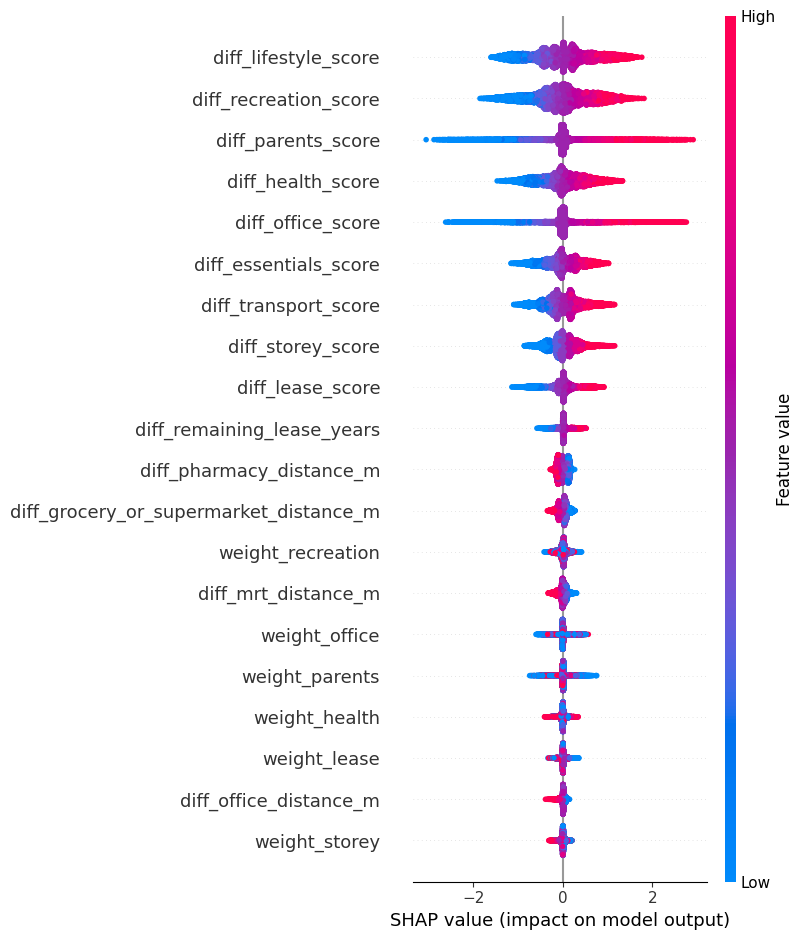

In [4]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, show=True)

### Bar Plot — Mean Absolute SHAP Values

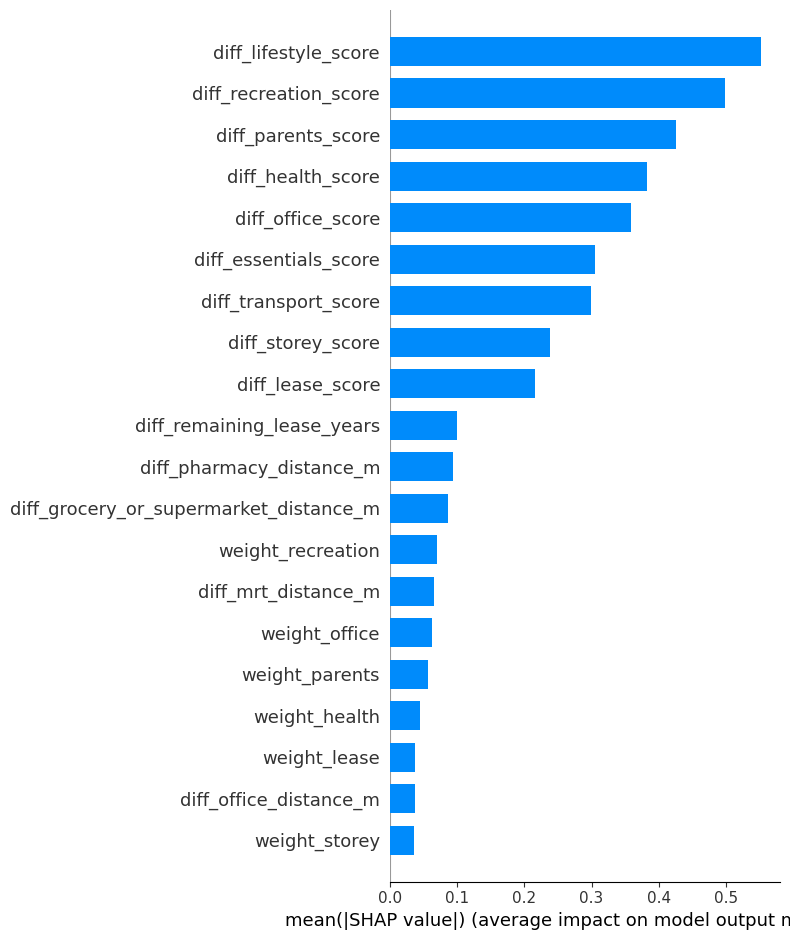

In [5]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, plot_type="bar", show=True)

### Dependence Plot — Weight × Score Interactions

Since the generative model is `sum(weight_i × score_i)`, we expect SHAP to show that  
`diff_transport_score` matters more when `weight_transport` is high.

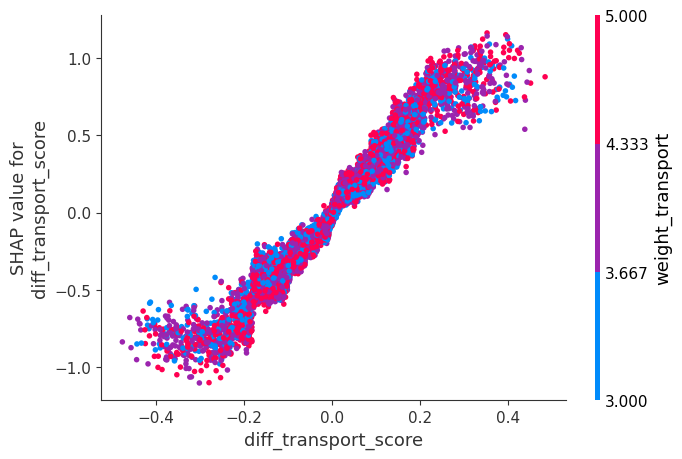

In [6]:
# Transport score dependence, colored by transport weight
shap.dependence_plot("diff_transport_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_transport",
                     show=True)

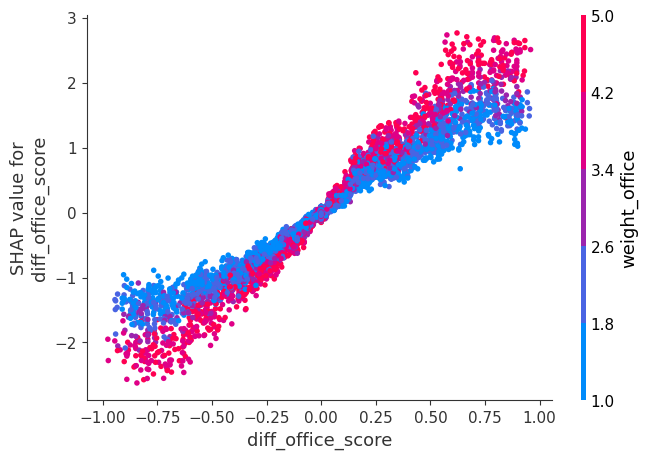

In [7]:
# Office score dependence, colored by office weight
shap.dependence_plot("diff_office_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_office",
                     show=True)

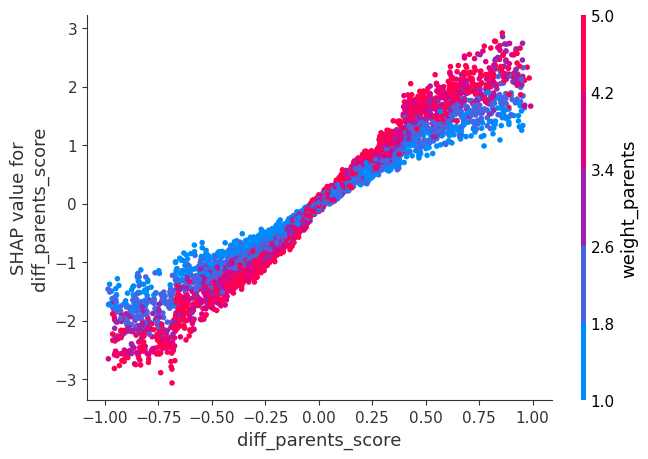

In [8]:
# Parents score dependence, colored by parents weight
shap.dependence_plot("diff_parents_score", shap_values_hgb, X_val,
                     feature_names=feature_cols,
                     interaction_index="weight_parents",
                     show=True)

---
## 2. MLP (RankNet) — SHAP KernelExplainer

KernelExplainer is model-agnostic but slower, so we subsample the background dataset.

In [9]:
# Subsample background data for KernelExplainer (100 samples for speed)
np.random.seed(42)
bg_idx = np.random.choice(len(X_val_scaled), size=100, replace=False)
background = X_val_scaled[bg_idx]

# Subsample explanation set (200 samples)
explain_idx = np.random.choice(len(X_val_scaled), size=200, replace=False)
X_explain = X_val_scaled[explain_idx]

explainer_mlp = shap.KernelExplainer(mlp_best.predict_proba, background)
shap_values_mlp = explainer_mlp.shap_values(X_explain)

# SHAP v0.51+ returns (n_samples, n_features, n_classes) instead of a list
if isinstance(shap_values_mlp, list):
    shap_values_mlp_1 = shap_values_mlp[1]
else:
    shap_values_mlp_1 = shap_values_mlp[:, :, 1]
print(f"MLP SHAP values shape: {shap_values_mlp_1.shape}")

100%|██████████| 200/200 [00:09<00:00, 20.58it/s]

MLP SHAP values shape: (200, 36)


### Summary Plot — MLP (RankNet)

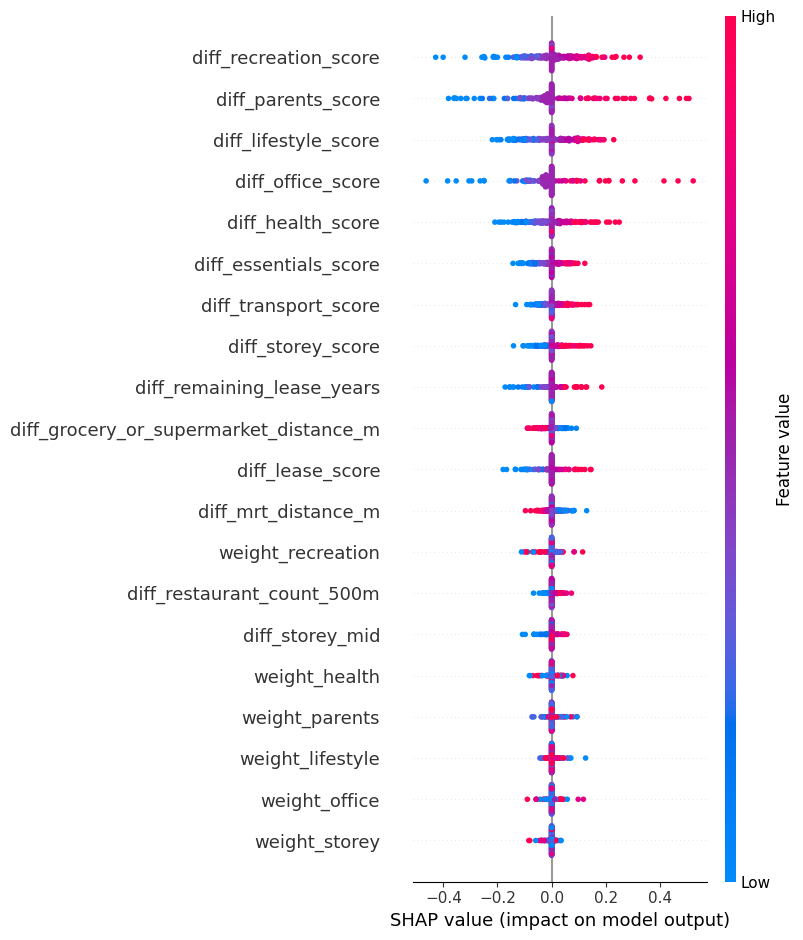

In [10]:
shap.summary_plot(shap_values_mlp_1, X_explain, feature_names=feature_cols, show=True)

---
## 3. Comparison: HistGBM vs MLP Feature Importance

Do both models agree on which features matter most?

In [11]:
# Mean absolute SHAP values per feature
hgb_importance = np.abs(shap_values_hgb).mean(axis=0)
mlp_importance = np.abs(shap_values_mlp_1).mean(axis=0)

comparison_df = pd.DataFrame({
    "feature": feature_cols,
    "HistGBM |SHAP|": hgb_importance,
    "MLP |SHAP|": mlp_importance,
})

# Rank features by importance for each model
comparison_df["HistGBM Rank"] = comparison_df["HistGBM |SHAP|"].rank(ascending=False).astype(int)
comparison_df["MLP Rank"] = comparison_df["MLP |SHAP|"].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values("HistGBM |SHAP|", ascending=False)

print("Feature Importance Comparison (Top 15)")
print("=" * 70)
comparison_df.head(15)

Feature Importance Comparison (Top 15)


,feature,HistGBM |SHAP|,MLP |SHAP|,HistGBM Rank,MLP Rank
11,diff_lifestyle_score,0.552606,0.066918,1,3
12,diff_recreation_score,0.498888,0.076683,2,1
17,diff_parents_score,0.426289,0.074709,3,2
13,diff_health_score,0.382424,0.051524,4,5
16,diff_office_score,0.358675,0.051851,5,4
10,diff_essentials_score,0.304447,0.032547,6,6
9,diff_transport_score,0.299103,0.028746,7,7
14,diff_storey_score,0.238800,0.025177,8,8
15,diff_lease_score,0.216299,0.019207,9,11
32,diff_remaining_lease_years,0.100370,0.021034,10,9
